0) Aplicar descenso del gradiente óptimo a la función :

$$f(x,y)=x^2+2y^2−2xy−2y$$ 

In [44]:
from sympy import *
import numpy as np
import math
import matplotlib.pyplot as plt

In [20]:
x, y = symbols('x y')

In [21]:
def hess(equation):
    x_equation = diff(equation,x)
    y_equation = diff(equation,y)

    sol = solve((x_equation, y_equation), y, x)

    xx_equation = int(diff(x_equation,x))
    yy_equation = int(diff(y_equation,y))
    xy_equation = diff(x_equation,y)
    yx_equation = diff(y_equation,x)

    hessian=np.array([[int(xx_equation),int(xy_equation)],[int(yx_equation),int(yy_equation)]])

    hessian_det = np.linalg.det(hessian)

    if hessian_det == 0:
        pass
    
    elif hessian_det > 0:
        if xx_equation > 0:
            print(f'Hay un mínimo local en {(sol[x],sol[y])}')

        else:
            print(f'Hay un máximo local en {(sol[x],sol[y])}')

    else:
        print(f'Hay un punto de silla en {(sol[x],sol[y])}')


    return (sol[x],sol[y])

In [22]:
def grad_f(equation,x0,alfa,tol,maxit):

    tabla_x, tabla_y, grad_x, grad_y = ([] for i in range(4))
    
    n_iter = 0
    
    if len(x0) > 1:

        punto = hess(equation)

        grad=[0,0]

        grad[0] = diff(equation,x).subs([(x,x0[0]),(y,x0[1])])
        grad[1] = diff(equation,y).subs([(x,x0[0]),(y,x0[1])])

        gradient_x = diff(equation,x)
        gradient_y = diff(equation,y)

        while n_iter < maxit :

            if abs(gradient_x.subs([(x,x0[0]),(y,x0[1])])) > tol:
                tabla_x.append(x0[0])
                grad_x.append(grad[0])
                grad[0] = grad[0] - alfa * gradient_x.subs([(x,x0[0]),(y,x0[1])])
                x0[0] = x0[0] - alfa * gradient_x.subs([(x,x0[0]),(y,x0[1])])

            if abs(gradient_y.subs([(x,x0[0]),(y,x0[1])])) > tol:
                tabla_y.append(x0[1])
                grad_y.append(grad[1])
                grad[1] = grad[1] - alfa *gradient_y.subs([(x,x0[0]),(y,x0[1])])
                x0[1] = x0[1] - alfa * gradient_y.subs([(x,x0[0]),(y,x0[1])])

            if abs(gradient_x.subs([(x,x0[0]),(y,x0[1])])) < tol and abs(gradient_y.subs([(x,x0[0]),(y,x0[1])])) < tol:

                return [grad_x,grad_y],[tabla_x,tabla_y],punto

            n_iter += 1

        return [grad_x,grad_y],[tabla_x,tabla_y],punto

In [42]:
def f(x_values, y_values):
    return x_values**2 + 2 * y_values**2 - 2*x_values*y_values - 2*y_values

In [34]:
ecuacion = x**2 + 2 * y**2 - 2*x*y - 2*y
gradient_descent = grad_f(ecuacion,[-1,-1],0.01,10**(-12),10**(5))

Hay un mínimo local en (1, 1)


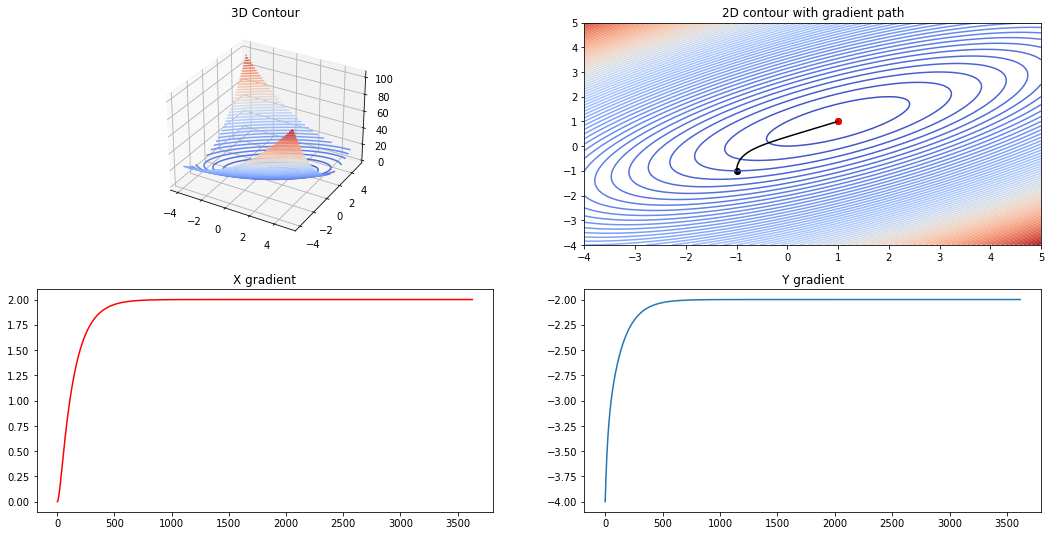

In [43]:
#Data of the plot
num = 5
X = np.linspace(int(-gradient_descent[1][0][0]) - num, int(gradient_descent[1][0][-1]) + num, 100)
Y = np.linspace(int(-gradient_descent[1][1][0]) - num, int(gradient_descent[1][1][-1]) + num, 100)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

#row,column,size of the plot
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(18,9))

#3D Contour
ax1.axis('off')
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.contour3D(X, Y, Z, 50, cmap='coolwarm')
ax1.set_title("3D Contour")

#2D Contour
ax2.contour(X, Y, Z, 100, cmap='coolwarm')
ax2.plot(gradient_descent[1][0][:-17], gradient_descent[1][1], '-k')
ax2.scatter(gradient_descent[1][0][0], gradient_descent[1][1][0], c='black')
ax2.scatter(gradient_descent[1][0][-1], gradient_descent[1][1][-1], c='black')
ax2.scatter(gradient_descent[-1][0], gradient_descent[-1][1], c='red')
ax2.set_title("2D contour with gradient path")

ax3.plot(gradient_descent[0][0],color='red')
ax3.set_title("X gradient")


ax4.plot(gradient_descent[0][1])
ax4.set_title("Y gradient")



plt.draw()
plt.show()

1) (Dos puntos adicionales) Optimizar la función mediante Descenso del Gradiente: estimar el gradiente o calcularlo analíticamente
$$f(x)=sin(1/2∗x^2−1/4∗y^2+3)∗cos(2∗x+1−e^y)$$

In [60]:
ecuacion = sin((1/2)*x**2 - (1/4) * y **2 + 3) * cos(2*x + 1 - math.e ** y)

In [61]:
ecuacion

sin(0.5*x**2 - 0.25*y**2 + 3)*cos(-2.71828182845905**y + 2*x + 1)

## Gradiente de x

In [65]:
dif_x = diff(ecuacion,x)
dif_x

1.0*x*cos(-2.71828182845905**y + 2*x + 1)*cos(0.5*x**2 - 0.25*y**2 + 3) - 2*sin(-2.71828182845905**y + 2*x + 1)*sin(0.5*x**2 - 0.25*y**2 + 3)

Se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial x} = x \cdot cos(a) \cdot cos(b) - 2 \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ x \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 2 \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{x}{2} \cdot (cos(a+b) + cos(a-b)) - cos(a-b) + cos(a+b) $$

por tanto, simplificando:
$$ grad(x) = cos(a+b) \cdot (\frac{x}{2} + 1) + cos(a-b) \cdot (\frac{x}{2} - 1) $$



## Gradiente de Y

In [66]:
dif_y = diff(ecuacion,y)
dif_y

1.0*2.71828182845905**y*sin(-2.71828182845905**y + 2*x + 1)*sin(0.5*x**2 - 0.25*y**2 + 3) - 0.5*y*cos(-2.71828182845905**y + 2*x + 1)*cos(0.5*x**2 - 0.25*y**2 + 3)

De manera análoga:, se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial y} = e^y \cdot cos(a) \cdot cos(b) - 0.5 \cdot y \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ e^y \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 0.5 \cdot y \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{e^y}{2} \cdot (cos(a+b) + cos(a-b)) - \frac{y}{4} \cdot(cos(a-b) - cos(a+b)) $$

por tanto, simplificando:
$$ grad(y) = cos(a+b) \cdot ( \frac{2 \cdot e^y + y}{4}) + cos(a+b) \cdot (\frac{2 \cdot e^y - y}{4}) $$



## Ambos gradientes

For tanto, se puede concluir que:

grad(f(x,y))